# BenchmarkResults Filtering Workflow (Production-Oriented)

This notebook demonstrates the updated `filter_results` behavior:

- Filtering is **global across all submissions** in `openfe_benchmarks/results`.
- Return values are `BenchmarkResults` objects for matching submissions.
- Entry-level filters (for `dg`/`ddg`) still work, but selection happens at submission level.
- When using `load_results=False`, you can load a specific submission later with `load_raw_results()`.

The workflow below uses practical checks that are useful for CI and analysis pipelines, with assertions that fail fast when behavior changes.

In [1]:
from pathlib import Path

from cinnabar import plotting

from openfe_benchmarks.results._benchmark_results import filter_results

In [2]:
all_submissions = filter_results(load_results=False)

print(f"Total submissions discovered: {len(all_submissions)}")
print(
    "Sample IDs:\n   ",
    "\n    ".join(sorted({item.submission_id for item in all_submissions})),
)

assert all_submissions, "Expected at least one submission in results directory"
assert all(hasattr(r, "submission_id") for r in all_submissions)

# With load_results=False, only metadata is loaded initially.
example_submission = all_submissions[0]
print(f"Before load_raw_results: raw_results is {example_submission.raw_results}")

# Load computational results later, only when needed.
example_submission.load_raw_results()
print(
    "After load_raw_results: raw_results loaded =",
    example_submission.raw_results is not None,
)

assert example_submission.raw_results is not None

Total submissions discovered: 9
Sample IDs:
    2026-02-12_sage_230_jacs_set
    2026-03-18-openmm-840-qa-testing
    2026-06-22-tyk2-alchemicalarchive-test
    2026-08-04-openff3.0.0-alpha1b_opc3-jacs
    2026-08-05-openff3.0.0-alpha1b_tip3p-jacs
    2026-08-05_ff14sb_openff-3.0.0-alpha1b_tip3p_jacs_tyk2_thrombin
    2026-08-05_openff-3.0.0-alpha0_opc3_jacs
    2026-08-06-openff-2.3.0-solvation_set_freesolv
    2026-08-25_ff14sb_openff-2.1.1_jacs
Before load_raw_results: raw_results is None
After load_raw_results: raw_results loaded = True


## 1) Production Metadata Filtering

These are fast, metadata-only queries (`load_results=False`) suitable for dashboards, CI checks, and release reports.

In [3]:
rbfe_submissions = filter_results(calculation_type="rbfe", load_results=False)
recent_submissions = filter_results(date=">=2026-01-01", load_results=False)
older_submissions = filter_results(date="<=2026-08-01", load_results=False)
newer_openfe_submissions = filter_results(openfe_version=">1.8.0", load_results=False)
non_test_submissions = filter_results(
    exclude_tags=["pontibus"], tags_mode="all", load_results=False
)

print(f"RBFE submissions: {len(rbfe_submissions)}")
print(f"Submissions since 2026-01-01: {len(recent_submissions)}")
print(f"Submissions on/before 2026-08-01: {len(older_submissions)}")
print(f"Submissions with openfe_version > 2.3.0: {len(newer_openfe_submissions)}")
print(f"Non-pontibus submissions: {len(non_test_submissions)}")

assert len(rbfe_submissions) <= len(all_submissions)
assert len(recent_submissions) <= len(all_submissions)
assert len(older_submissions) <= len(all_submissions)
assert len(newer_openfe_submissions) <= len(all_submissions)
assert len(non_test_submissions) <= len(all_submissions)

RBFE submissions: 8
Submissions since 2026-01-01: 9
Submissions on/before 2026-08-01: 3
Submissions with openfe_version > 2.3.0: 1
Non-pontibus submissions: 5


## 2) Entry-Level Filtering, Submission-Level Return

These queries inspect `dg`/`ddg` entries but return whole `BenchmarkResults` submissions. This is useful in production when downstream steps need both metadata and raw result context.

In [4]:
tyk2_related = filter_results(system_name="tyk2", load_results=True)

print(f"Submissions containing tyk2-like system names: {len(tyk2_related)}")
print("Example IDs:", sorted({item.submission_id for item in tyk2_related})[:5])

assert isinstance(tyk2_related, list)
assert all(hasattr(r, "raw_results") for r in tyk2_related)

Submissions containing tyk2-like system names: 8
Example IDs: ['2026-02-12_sage_230_jacs_set', '2026-03-18-openmm-840-qa-testing', '2026-06-22-tyk2-alchemicalarchive-test', '2026-08-04-openff3.0.0-alpha1b_opc3-jacs', '2026-08-05-openff3.0.0-alpha1b_tip3p-jacs']


## 3) Double-Underscore Filtering Demonstration

- A query with a real nested value returns submissions that actually exist.
- A query with an impossible nested value returns no submissions.

This is the production behavior you want when building search/reporting workflows.

In [5]:
# Positive case: concrete nested value that should exist.
chosen_key = "protocol_settings__protocol"
chosen_value = "RelativeHybridTopologyProtocol"
positive_result = filter_results(load_results=False, **{chosen_key: chosen_value})
positive_ids = {item.submission_id for item in positive_result}

# Negative case: concrete nested value that should not exist.
negative_result = filter_results(
    load_results=False, protocol_settings__protocol="ProtocolThatDoesNotExist"
)
negative_ids = {item.submission_id for item in negative_result}

print(f"Nested key used: {chosen_key}")
print(f"Existing value: {chosen_value}")
print(f"Existing-value matches: {len(positive_ids)}")
print("Sample matched IDs:", sorted(positive_ids)[:5])
print(f"Impossible-value matches: {len(negative_ids)}")

assert len(positive_ids) > 0, "Expected nested query to return existing submissions"
assert len(negative_ids) == 0, (
    "Expected impossible nested query to return no submissions"
)

Nested key used: protocol_settings__protocol
Existing value: RelativeHybridTopologyProtocol
Existing-value matches: 5
Sample matched IDs: ['2026-02-12_sage_230_jacs_set', '2026-03-18-openmm-840-qa-testing', '2026-06-22-tyk2-alchemicalarchive-test', '2026-08-05_ff14sb_openff-3.0.0-alpha1b_tip3p_jacs_tyk2_thrombin', '2026-08-25_ff14sb_openff-2.1.1_jacs']
Impossible-value matches: 0


## 4) DG/DDG to Cinnabar Plot Demonstration

These examples show how filtered submissions feed directly into cinnabar plotting:

- DG plotting from ASFE submissions via `results.dg_femaps()` and `plotting.plot_DGs`
- DDG plotting from RBFE submissions via `results.ddg_femaps()` and `plotting.plot_DDGs`

Plots are written to a local `outputs/` directory.

### 4.1 Understanding the `source` Parameter

Both `dg_femaps()` and `ddg_femaps()` accept an optional `source` parameter that controls the source identifier in the FEMap data.

**Default behavior** (when `source=None`):
- The source defaults to the submission's `submission_id`
- This is useful for tracking which submission/methodology produced each result

**Custom source** (when `source="CustomName"`):
- Override the default identifier with a custom string
- Useful when plotting multiple submissions together or comparing different naming schemes
- Must match the `source` values expected by cinnabar plotting functions

Example usage:
```python
# Uses default: source will be the submission_id
femaps = results.dg_femaps()

# Custom source: override to use a specific identifier
femaps = results.dg_femaps(source="Computational")
```

### 4.2 DG Plot Example (ASFE)

Use a real ASFE submission and plot computed vs experimental DG values with cinnabar.

We show both:
- Using the **default source** (submission_id)
- **Overriding source** to customize the plot label

2026-08-28 11:42:26 - openfe_benchmarks.results._benchmark_results - INFO - Computing FEMaps for dg results - first access may be slow
2026-08-28 11:42:26 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'freesolv' from benchmark set 'solvation_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: False.
  Found 0 ligand network files with keys: 


Default source in FEMap: 2026-08-06-openff-2.3.0-solvation_set_freesolv
ASFE submission: 2026-08-06-openff-2.3.0-solvation_set_freesolv
System: solvation_set/freesolv
Saved DG plot (default source): outputs/2026-08-06-openff-2.3.0-solvation_set_freesolv_solvation_set_freesolv_DG_default.png



2026-08-28 11:42:28 - openfe_benchmarks.results._benchmark_results - INFO - Computing FEMaps for dg results - first access may be slow
2026-08-28 11:42:28 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'freesolv' from benchmark set 'solvation_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: False.
  Found 0 ligand network files with keys: 


Custom source in FEMap: OpenFE-Benchmark-Suite
Saved DG plot (custom source): outputs/2026-08-06-openff-2.3.0-solvation_set_freesolv_solvation_set_freesolv_DG_custom.png


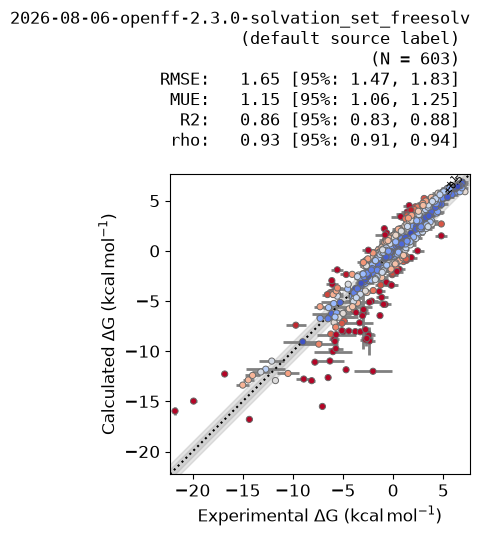

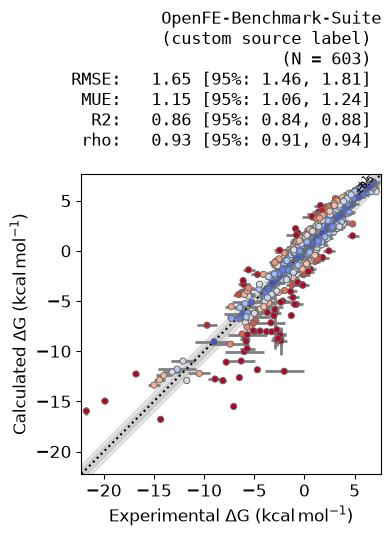

In [6]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# Load ASFE submission for Example 1 (default source)
asfe_submission_1 = filter_results(calculation_type="asfe", load_results=True)[0]

# Example 1: Using default source (submission_id)
(system_group, system_name), dg_femap_default = next(
    iter(asfe_submission_1.dg_femaps().items())
)

# Extract the actual source from the FEMap data
print(f"Default source in FEMap: {asfe_submission_1.submission_id}")

dg_plot_file_default = (
    output_dir
    / f"{asfe_submission_1.submission_id}_{system_group}_{system_name}_DG_default.png"
)
plotting.plot_DGs(
    dg_femap_default,
    source=asfe_submission_1.submission_id,  #  <- must be the same as source used for the data
    title=f"{asfe_submission_1.submission_id}\n(default source label)",
    figsize=5,
    scatter_kwargs={"s": 20, "marker": "o"},
    filename=dg_plot_file_default.as_posix(),
)

print(f"ASFE submission: {asfe_submission_1.submission_id}")
print(f"System: {system_group}/{system_name}")
print(f"Saved DG plot (default source): {dg_plot_file_default}")
print()

# Load a fresh ASFE submission for Example 2 (custom source)
# This is needed because FEMap results are cached after first access
asfe_submission_2 = filter_results(calculation_type="asfe", load_results=True)[0]

# Example 2: Using custom source override
custom_source_label = "OpenFE-Benchmark-Suite"
dg_femap_custom = asfe_submission_2.dg_femaps(source=custom_source_label)
(system_group, system_name), dg_femap_custom = next(iter(dg_femap_custom.items()))

print(f"Custom source in FEMap: {custom_source_label}")

dg_plot_file_custom = (
    output_dir
    / f"{asfe_submission_2.submission_id}_{system_group}_{system_name}_DG_custom.png"
)
plotting.plot_DGs(
    dg_femap_custom,
    source=custom_source_label,  # Use the actual custom source from the data
    title=f"{custom_source_label}\n(custom source label)",
    figsize=5,
    scatter_kwargs={"s": 20, "marker": "o"},
    filename=dg_plot_file_custom.as_posix(),
)

print(f"Saved DG plot (custom source): {dg_plot_file_custom}")

### 4.3 DDG Plot Example (RBFE)

Use a real RBFE submission and plot computed vs experimental DDG values with cinnabar.

Demonstrates extracting available sources from the data and both default and custom source behavior.

2026-08-28 11:42:30 - openfe_benchmarks.results._benchmark_results - INFO - Computing FEMaps for ddg results - first access may be slow
2026-08-28 11:42:30 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'jnk1' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-28 11:42:30 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'thrombin' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-28 11:42:30 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'cdk2' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-28 11:42:30 - openfe_benchmarks.data

Available sources in data: ['2026-02-12_sage_230_jacs_set', 'experimental']
Default source (submission_id): 2026-02-12_sage_230_jacs_set

RBFE submission: 2026-02-12_sage_230_jacs_set
System: jacs_set/jnk1
Saved DDG plot (default source): outputs/2026-02-12_sage_230_jacs_set_jacs_set_jnk1_DDG_default.png


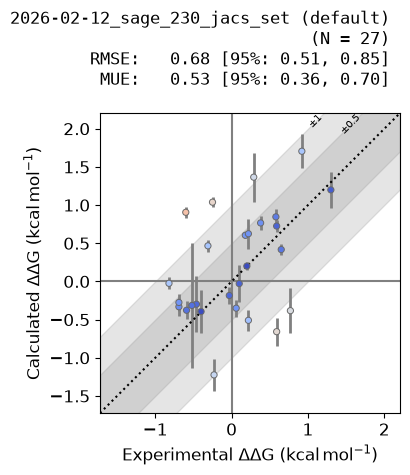

In [7]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

rbfe_submission = filter_results(calculation_type="rbfe", load_results=True)[0]

# Example 1: Using default source (submission_id)
ddg_femap_default = rbfe_submission.ddg_femaps()  # source defaults to submission_id
(system_group, system_name), ddg_femap = next(iter(ddg_femap_default.items()))

relative_df = ddg_femap.get_relative_dataframe()
available_sources = sorted(set(relative_df["source"].fillna("")))
print(f"Available sources in data: {available_sources}")
print(f"Default source (submission_id): {rbfe_submission.submission_id}")

ddg_plot_file_default = (
    output_dir
    / f"{rbfe_submission.submission_id}_{system_group}_{system_name}_DDG_default.png"
)
plotting.plot_DDGs(
    ddg_femap,
    source=rbfe_submission.submission_id,  # Use the default submission_id
    title=f"{rbfe_submission.submission_id} (default)",
    figsize=5,
    scatter_kwargs={"s": 20, "marker": "o"},
    filename=ddg_plot_file_default.as_posix(),
)

print(f"\nRBFE submission: {rbfe_submission.submission_id}")
print(f"System: {system_group}/{system_name}")
print(f"Saved DDG plot (default source): {ddg_plot_file_default}")

2026-08-28 11:42:30 - openfe_benchmarks.results._benchmark_results - INFO - Regenerating ddg_femaps with new source='OpenFE-Suite-v1.0' (previous: '2026-02-12_sage_230_jacs_set')
2026-08-28 11:42:30 - openfe_benchmarks.results._benchmark_results - INFO - Computing FEMaps for ddg results - first access may be slow
2026-08-28 11:42:30 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'jnk1' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-28 11:42:30 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'thrombin' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-28 11:42:30 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'cdk2' from benchmark set 'jacs_set' with:
  5 lig

Saved DDG plot (custom source): outputs/2026-02-12_sage_230_jacs_set_jacs_set_jnk1_DDG_custom.png


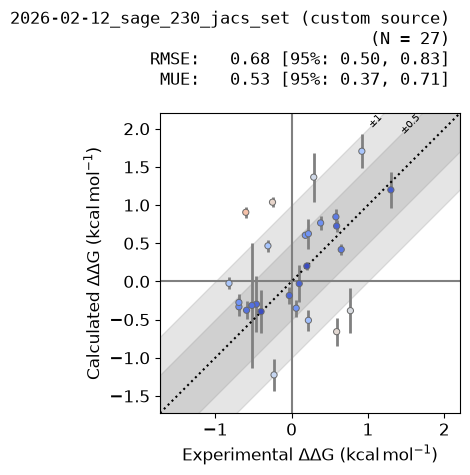

In [8]:
# Example 2: Using custom source override
custom_source_label = "OpenFE-Suite-v1.0"
ddg_femap_custom = rbfe_submission.ddg_femaps(
    source=custom_source_label, force_source_update=True
)
(system_group, system_name), ddg_femap_custom = next(iter(ddg_femap_custom.items()))

ddg_plot_file_custom = (
    output_dir
    / f"{rbfe_submission.submission_id}_{system_group}_{system_name}_DDG_custom.png"
)
plotting.plot_DDGs(
    ddg_femap_custom,
    source=custom_source_label,
    title=f"{rbfe_submission.submission_id} (custom source)",
    figsize=5,
    scatter_kwargs={"s": 20, "marker": "o"},
    filename=ddg_plot_file_custom.as_posix(),
)

print(f"Saved DDG plot (custom source): {ddg_plot_file_custom}")